#Data Cleaning Project using the Google Play Store Apps Dataset (Kaggle)

Importing Dataset from the drive

In [8]:
#1.Mount Google Drive

from google.colab import drive
drive.mount('/content/drive')

#2. Load the CSV
import pandas as pd
file_path ='/content/drive/My Drive/Datasets/googleplaystore.csv'

df = pd.read_csv(file_path)

print(df.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
                                                 App        Category  Rating  \
0     Photo Editor & Candy Camera & Grid & ScrapBook  ART_AND_DESIGN     4.1   
1                                Coloring book moana  ART_AND_DESIGN     3.9   
2  U Launcher Lite – FREE Live Cool Themes, Hide ...  ART_AND_DESIGN     4.7   
3                              Sketch - Draw & Paint  ART_AND_DESIGN     4.5   
4              Pixel Draw - Number Art Coloring Book  ART_AND_DESIGN     4.3   

  Reviews  Size     Installs  Type Price Content Rating  \
0     159   19M      10,000+  Free     0       Everyone   
1     967   14M     500,000+  Free     0       Everyone   
2   87510  8.7M   5,000,000+  Free     0       Everyone   
3  215644   25M  50,000,000+  Free     0           Teen   
4     967  2.8M     100,000+  Free     0       Everyone   

                      Genres      L

In [9]:
df['Size'].unique()

array(['19M', '14M', '8.7M', '25M', '2.8M', '5.6M', '29M', '33M', '3.1M',
       '28M', '12M', '20M', '21M', '37M', '2.7M', '5.5M', '17M', '39M',
       '31M', '4.2M', '7.0M', '23M', '6.0M', '6.1M', '4.6M', '9.2M',
       '5.2M', '11M', '24M', 'Varies with device', '9.4M', '15M', '10M',
       '1.2M', '26M', '8.0M', '7.9M', '56M', '57M', '35M', '54M', '201k',
       '3.6M', '5.7M', '8.6M', '2.4M', '27M', '2.5M', '16M', '3.4M',
       '8.9M', '3.9M', '2.9M', '38M', '32M', '5.4M', '18M', '1.1M',
       '2.2M', '4.5M', '9.8M', '52M', '9.0M', '6.7M', '30M', '2.6M',
       '7.1M', '3.7M', '22M', '7.4M', '6.4M', '3.2M', '8.2M', '9.9M',
       '4.9M', '9.5M', '5.0M', '5.9M', '13M', '73M', '6.8M', '3.5M',
       '4.0M', '2.3M', '7.2M', '2.1M', '42M', '7.3M', '9.1M', '55M',
       '23k', '6.5M', '1.5M', '7.5M', '51M', '41M', '48M', '8.5M', '46M',
       '8.3M', '4.3M', '4.7M', '3.3M', '40M', '7.8M', '8.8M', '6.6M',
       '5.1M', '61M', '66M', '79k', '8.4M', '118k', '44M', '695k', '1.6M',
     

We need to standardize everything into Megabytes(M)

In [10]:
import numpy as np

def clean_size(size):
  if 'M' in str(size):
    return float(size.replace('M',''))
  elif 'k' in str(size):
    return float(size.replace('k',''))/1024
  elif 'Varies with device' in str(size):
    return np.nan
  else:
    return np.nan

#Make new column and apply the function
df['Size_MB'] = df['Size'].apply(clean_size)

print(df[['Size','Size_MB']].head(10))

   Size  Size_MB
0   19M     19.0
1   14M     14.0
2  8.7M      8.7
3   25M     25.0
4  2.8M      2.8
5  5.6M      5.6
6   19M     19.0
7   29M     29.0
8   33M     33.0
9  3.1M      3.1


Cleaning the 'Installs' and ' Price' columns

In [13]:
#Remove the glitchy row where Installs == "Free"
df = df[df['Installs'] != 'Free']

# 1. Clean 'Installs'
# We chain two replaces: remove '+' AND remove ','
# Then convert to integer
df['Installs'] = df['Installs'].str.replace('+', '').str.replace(',', '')
df['Installs'] = df['Installs'].astype(int)

# 2. Clean 'Price'
# Remove the '$' sign
df['Price'] = df['Price'].str.replace('$', '')
df['Price'] = df['Price'].astype(float)

# 3. Check the results
print(df[['Installs', 'Price']].head())
print("\nData Types:")
print(df[['Installs', 'Price']].dtypes)

   Installs  Price
0     10000    0.0
1    500000    0.0
2   5000000    0.0
3  50000000    0.0
4    100000    0.0

Data Types:
Installs      int64
Price       float64
dtype: object


/tmp/ipython-input-3957344228.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Installs'] = df['Installs'].str.replace('+', '').str.replace(',', '')
/tmp/ipython-input-3957344228.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Installs'] = df['Installs'].astype(int)
/tmp/ipython-input-3957344228.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https:

In [14]:
df

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Size_MB
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,10000,Free,0.0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up,19.0
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,500000,Free,0.0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,14.0
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,5000000,Free,0.0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up,8.7
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,50000000,Free,0.0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up,25.0
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,100000,Free,0.0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up,2.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10836,Sya9a Maroc - FR,FAMILY,4.5,38,53M,5000,Free,0.0,Everyone,Education,"July 25, 2017",1.48,4.1 and up,53.0
10837,Fr. Mike Schmitz Audio Teachings,FAMILY,5.0,4,3.6M,100,Free,0.0,Everyone,Education,"July 6, 2018",1.0,4.1 and up,3.6
10838,Parkinson Exercices FR,MEDICAL,NaN,3,9.5M,1000,Free,0.0,Everyone,Medical,"January 20, 2017",1.0,2.2 and up,9.5
10839,The SCP Foundation DB fr nn5n,BOOKS_AND_REFERENCE,4.5,114,Varies with device,1000,Free,0.0,Mature 17+,Books & Reference,"January 19, 2015",Varies with device,Varies with device,NaN


Finding the top 10 categories

/tmp/ipython-input-2816001404.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='Category', data=df,order=top_categories,palette='viridis')


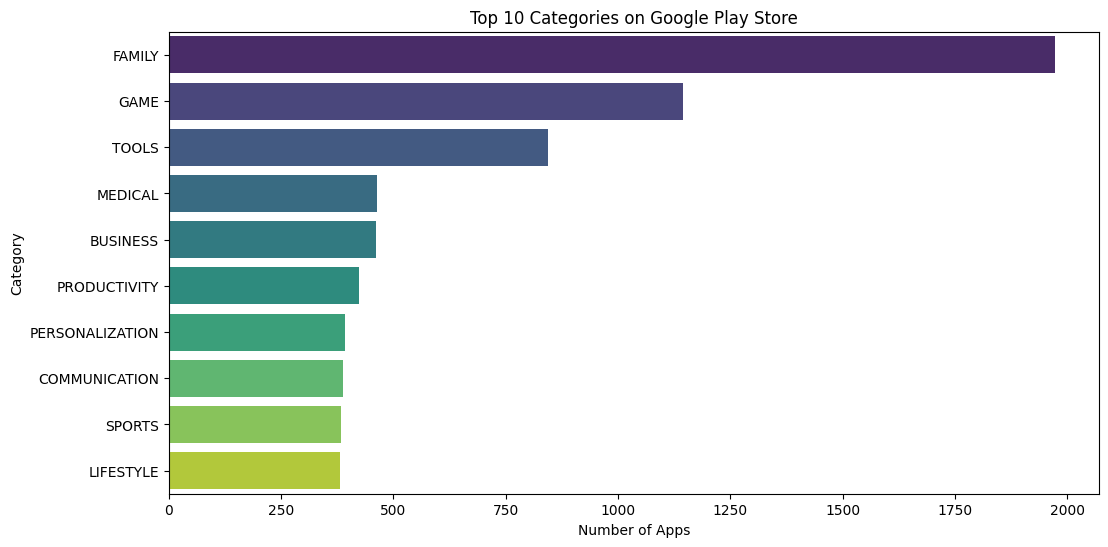

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

#Get the top 10 categories by count
top_categories = df['Category'].value_counts().head(10).index

#Plot
plt.figure(figsize=(12,6))
sns.countplot(y='Category', data=df,order=top_categories,palette='viridis')

plt.title('Top 10 Categories on Google Play Store')
plt.xlabel('Number of Apps')
plt.ylabel('Category')
plt.show()

Do people complain more about free apps than paid apps? (Using a Boxplot)

/tmp/ipython-input-2343819959.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Type', y='Rating', data=df, palette='coolwarm')


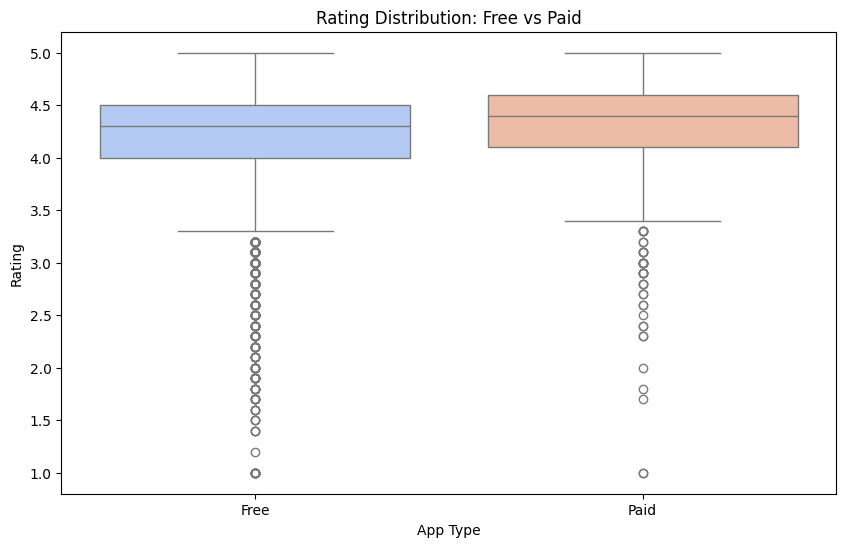

In [16]:
plt.figure(figsize=(10,6))
sns.boxplot(x='Type', y='Rating', data=df, palette='coolwarm')

plt.title('Rating Distribution: Free vs Paid')
plt.xlabel('App Type')
plt.ylabel('Rating')
plt.show()

If I make the app too big, will fewer people download it? (Using Scatter Plot)

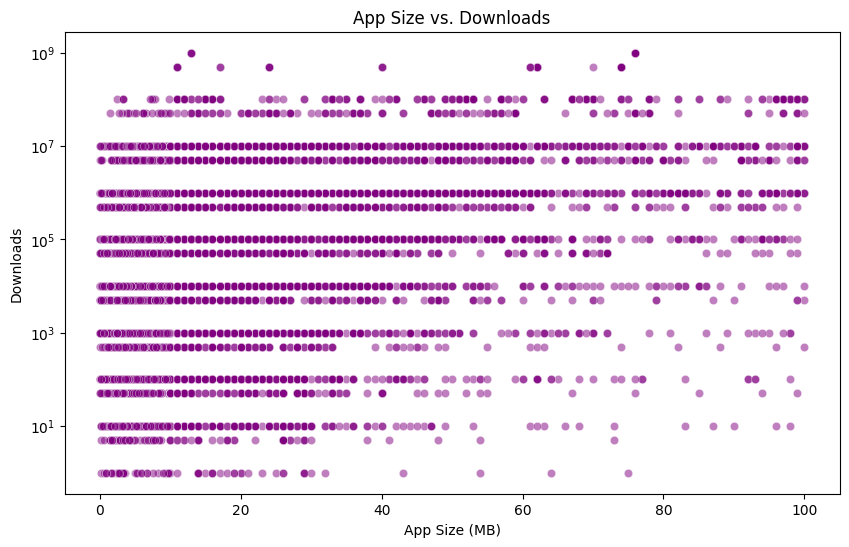

In [21]:
plt.figure(figsize=(10,6))

#Using 'alpha=0.5' to make dots transparent so we can see clusters
sns.scatterplot(x='Size_MB', y='Installs', data=df,alpha=0.5,color='purple')

plt.title('App Size vs. Downloads')
plt.xlabel('App Size (MB)')
plt.ylabel('Downloads')

plt.yscale('log')
plt.show()

Save the cleaned dataset

In [22]:
df.to_csv('/content/drive/My Drive/Datasets/cleaned_googleplaystore.csv', index=False)